# Example 11a: symmetry-reduced Pulse Design Tool

This example builds a self-contained analytic toy tokamak, prepares it for exact
up-down symmetry, and evolves it with the Pulse Design Tool while retaining only
even-in-Z passive modes.

The reduction rests on a local property of an exactly even machine and plasma.
If (S) is up-down reflection and (A) is the evolution operator linearised
around an even equilibrium, then

\[
S^T=S,\qquad S^2=I,\qquad SA=AS.
\]

The (+1) (even) and (-1) (odd) eigenspaces of (S) are orthogonal. Because
(A) commutes with (S), each is also invariant under the linearised dynamics:
an even perturbation cannot drive an odd response, or vice versa. Retaining only
the even subspace therefore reproduces full symmetric dynamics while removing
the fast vertical modes. This is exact for the linearisation around an even
state; machine or plasma asymmetry and finite nonlinear departures can couple
the two parities.

The example deliberately separates four operations:

1. audit and symmetrise an approximately symmetric machine description;
2. construct an exactly symmetric initial Grad-Shafranov equilibrium;
3. inspect the retained and discarded passive modes;
4. use **SymmetryReducedSolver** behind the standard plasma-control loop.

No MAST-U data, UDA access, or machine-description files are used. The odd
vertical-control circuit included in the source description exists only to show
that strict preparation detects and excludes it explicitly.

## 1. Build the analytic source machine

Active coils and passive structures are placed in reflected pairs around
\(Z=0\). Four shaping pairs become four series circuits in the even machine.
The solenoid is internally symmetric. A fifth source circuit has opposite
upper/lower winding polarity and is therefore odd.

The limiter radius is chosen not to pass exactly through grid nodes. This avoids
a geometric boundary point being classified differently on the two sides by
floating-point point-in-polygon tests.


In [1]:
import time

import matplotlib.pyplot as plt
import numpy as np

from freegsnke import GSstaticsolver, build_machine, equilibrium_update
from freegsnke.inverse import Inverse_optimizer
from freegsnke.jtor_update import Lao85
from freegsnke.up_down_symmetry import prepare_up_down_symmetric_machine


def active_element(r, z, multiplier=100, polarity=1):
    """Return one rectangular active-coil filament bundle."""
    return {
        "R": [r],
        "Z": [z],
        "dR": 0.06,
        "dZ": 0.06,
        "resistivity": 1.55e-8,
        "polarity": polarity,
        "multiplier": multiplier,
    }


def analytic_source_machine():
    """Build an approximately machine-shaped, exactly paired toy description."""
    major_radius = 1.0
    active = {
        "solenoid": {
            **active_element(0.28, 0.0, multiplier=20),
            "R": [0.28] * 4,
            "Z": [-0.55, -0.18, 0.18, 0.55],
        }
    }

    upper_angles = (np.pi / 4, 3 * np.pi / 4, np.pi / 8, 7 * np.pi / 8)
    for index, angle in enumerate(upper_angles, start=1):
        r = major_radius + 0.70 * np.cos(angle)
        z = 0.70 * np.sin(angle)
        active[f"shape_{index}_upper"] = active_element(r, z)
        active[f"shape_{index}_lower"] = active_element(r, -z)

    active["vertical_control"] = {
        "upper": active_element(1.68, 0.28),
        "lower": active_element(1.68, -0.28, polarity=-1),
    }

    passive = []
    for index, angle in enumerate(np.linspace(np.pi / 20, 19 * np.pi / 20, 10)):
        r = major_radius + 0.50 * np.cos(angle)
        z = 0.50 * np.sin(angle)
        half_width = 0.025
        for side, z_centre in (("upper", z), ("lower", -z)):
            passive.append(
                {
                    "name": f"shell_{index}_{side}",
                    "element": f"shell_{index}",
                    "R": np.array(
                        [
                            r - half_width,
                            r + half_width,
                            r + half_width,
                            r - half_width,
                        ]
                    ),
                    "Z": np.array(
                        [
                            z_centre - half_width,
                            z_centre - half_width,
                            z_centre + half_width,
                            z_centre + half_width,
                        ]
                    ),
                    "resistivity": 5.5e-7,
                }
            )

    theta = np.linspace(0.0, 2 * np.pi, 96, endpoint=False)
    limiter = [
        {
            "R": float(major_radius + 0.44 * np.cos(angle)),
            "Z": float(0.44 * np.sin(angle)),
        }
        for angle in theta
    ]
    return active, passive, limiter

### Audit and prepare the machine

The first call uses strict preparation and intentionally reports the odd active
circuit. The second call excludes that circuit explicitly and returns both the
even machine description and the passive reflection operator needed by the
reduced solver. No circuit is silently discarded.

In [2]:
active_source, passive_source, limiter_source = analytic_source_machine()

try:
    prepare_up_down_symmetric_machine(
        active_source,
        passive_source,
        limiter_data=limiter_source,
        wall_data=limiter_source,
    )
except ValueError as error:
    print("Strict preflight:", error)

prepared = prepare_up_down_symmetric_machine(
    active_source,
    passive_source,
    limiter_data=limiter_source,
    wall_data=limiter_source,
    exclude_odd_active=True,
)
print("Retained even circuits:", prepared.even_active_names)
print("Explicitly excluded odd circuits:", prepared.excluded_odd_active_names)
print("Passive reflection pairs:", len(prepared.passive_pairs))

Strict preflight: Electrically odd active circuits cannot be included in strict even evolution: ('vertical_control',). Pass 'exclude_odd_active=True' to omit and record them explicitly.
Retained even circuits: ('solenoid', 'shape_1', 'shape_2', 'shape_3', 'shape_4')
Explicitly excluded odd circuits: ('vertical_control',)
Passive reflection pairs: 10


## 2. Construct an exactly symmetric initial equilibrium

The prepared geometry is used directly to build the tokamak. The small
reflection averages below make the numerically sampled Green functions,
resistances, and inductances commute exactly with the machine reflection map.

A symmetric inverse solve then finds the four shaping-circuit currents. The
solenoid current is fixed during that solve because its role is plasma-current
control, not shape control. Upper and lower null constraints are supplied as a
reflected pair, and every forward solve used by the inverse is projected onto
the even plasma subspace.


In [3]:
tokamak = build_machine.tokamak(
    active_coils_data=prepared.even_active_coils_data,
    passive_coils_data=prepared.passive_coils_data,
    limiter_data=prepared.limiter_data,
    wall_data=prepared.wall_data,
)
eq = equilibrium_update.Equilibrium(
    tokamak=tokamak,
    Rmin=0.1,
    Rmax=1.9,
    Zmin=-0.8,
    Zmax=0.8,
    nx=65,
    ny=65,
)

eq._vgreen = prepared.symmetrise_even_machine_greens(eq._vgreen)
tokamak.coil_resist = prepared.symmetrise_even_machine_resistances(
    tokamak.coil_resist
)
tokamak.coil_self_ind = prepared.symmetrise_even_machine_square_operator(
    tokamak.coil_self_ind
)

profiles = Lao85(
    eq=eq,
    Ip=2.0e5,
    fvac=0.5,
    alpha=[58213.6],
    beta=[0.582136],
)
tokamak.set_coil_current("solenoid", 3000.0)
tokamak["solenoid"].control = False

constraints = Inverse_optimizer(
    null_points=[[0.8, 0.8], [0.35, -0.35]],
    isoflux_set=np.array([[[0.8, 0.8, 1.22], [0.35, -0.35, 0.0]]]),
    weight_isoflux=1.0,
    weight_nulls=0.8,
)
static_solver = GSstaticsolver.NKGSsolver(eq)
static_solver.inverse_solve(
    eq=eq,
    profiles=profiles,
    constrain=constraints,
    target_relative_tolerance=1e-5,
    target_relative_psit_update=1e-3,
    l2_reg=np.full(4, 1e-8),
    force_up_down_symmetric=True,
    verbose=False,
)


def selected_lower_xpoint(equilibrium):
    """Select the lower null nearest the inverse-solve target."""
    lower = equilibrium.xpt[equilibrium.xpt[:, 1] < 0]
    target = np.array([0.8, -0.35])
    return lower[np.argmin(np.linalg.norm(lower[:, :2] - target, axis=1)), :2]


def plasma_descriptors(equilibrium):
    """Return the four shape measurements used by the controller."""
    rin, rout = equilibrium.innerOuterSeparatrix()
    rx, zx = selected_lower_xpoint(equilibrium)
    return np.array([rin, rout, rx, zx])


active_coils = list(tokamak.coils_list[: tokamak.n_active_coils])
n_active = len(active_coils)
ctrl_targets = ["Rin", "Rout", "Rx", "Zx"]
print("Active circuit order:", active_coils)
print("Initial active currents [A]:", tokamak.getCurrentsVec()[:n_active])
print("Initial descriptors [m]:", plasma_descriptors(eq))


Active coils --> built from user-provided data.
Passive structures --> built from user-provided data.
Limiter --> built from user-provided data.
Wall --> built from user-provided data.
Magnetic probes --> none provided.
Resistance (R) and inductance (M) matrices --> built using actives (and passives if present).
Tokamak built.


Inverse static solve SUCCESS. Tolerance 5.36e-06 (vs. requested 1e-05) reached in 11/100 iterations.
Active circuit order: ['solenoid', 'shape_1', 'shape_2', 'shape_3', 'shape_4']
Initial active currents [A]: [ 3000.          -407.79163325  5786.56312109  -199.98755802
 -3926.99438414]
Initial descriptors [m]: [ 0.79903974  1.23546403  0.81525829 -0.35062376]


### Symmetry audit

Let \(S_m\) denote the metal-current reflection operator. Exact reduced
evolution requires the machine operators to commute with \(S_m\), the limiter
mask to be reflection invariant, and the initial plasma fields and metal
currents to be even. The following relative errors should be at round-off.


sampled Green functions    : 0.000e+00
inductance operator        : 0.000e+00
resistance operator        : 0.000e+00
plasma flux                : 0.000e+00
toroidal current density   : 0.000e+00
metal currents             : 0.000e+00
limiter-mask defects       : 0


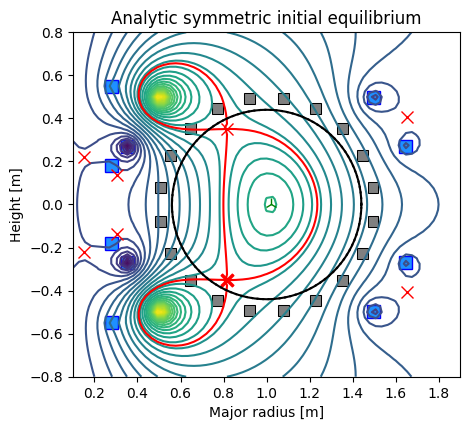

In [4]:
passive_reflection_operator = prepared.passive_reflection_operator
reflection_operator = prepared.even_machine_reflection_operator


def relative_reflection_error(values, parity=1):
    denominator = np.linalg.norm(values)
    if denominator == 0:
        return 0.0
    return np.linalg.norm(values - parity * values[:, ::-1]) / denominator


def relative_commutator_error(matrix):
    numerator = np.linalg.norm(
        reflection_operator @ matrix - matrix @ reflection_operator
    )
    return numerator / np.linalg.norm(matrix)


reflected_greens = np.einsum(
    "ij,jrz->irz", reflection_operator, eq._vgreen[:, :, ::-1]
)
resistance_matrix = np.diag(tokamak.coil_resist)
initial_currents = tokamak.getCurrentsVec()
symmetry_errors = {
    "sampled Green functions": (
        np.linalg.norm(eq._vgreen - reflected_greens)
        / np.linalg.norm(eq._vgreen)
    ),
    "inductance operator": relative_commutator_error(tokamak.coil_self_ind),
    "resistance operator": relative_commutator_error(resistance_matrix),
    "plasma flux": relative_reflection_error(eq.plasma_psi),
    "toroidal current density": relative_reflection_error(profiles.jtor),
    "metal currents": (
        np.linalg.norm(reflection_operator @ initial_currents - initial_currents)
        / np.linalg.norm(initial_currents)
    ),
}
limiter_defects = np.count_nonzero(
    eq.limiter_handler.mask_inside_limiter
    != eq.limiter_handler.mask_inside_limiter[:, ::-1]
)

for name, error in symmetry_errors.items():
    print(f"{name:27s}: {error:.3e}")
print(f"{'limiter-mask defects':27s}: {limiter_defects}")
assert max(symmetry_errors.values()) < 1e-12
assert limiter_defects == 0

fig, axis = plt.subplots(figsize=(5, 5))
eq.plot(axis=axis, show=False)
tokamak.plot(axis=axis, show=False)
axis.set_xlim(0.1, 1.9)
axis.set_ylim(-0.8, 0.8)
axis.set_aspect("equal")
axis.set_title("Analytic symmetric initial equilibrium")
plt.show()


## 3. Build local shape responses for the PCS

The toy machine has no precomputed virtual-circuit data. Instead, four
symmetric finite-difference GS solves construct

\[
S_{kj} = \frac{\partial s_k}{\partial I_j},
\]

for the four shaping circuits. The pseudo-inverse \(S^+\) maps a requested
descriptor correction to coil-current requests. The solenoid row is set to zero
for all shape targets; plasma-current control uses the solenoid alone.

These finite-difference solves are only part of controller setup. The
symmetry-reduced evolutive solver builds its own plasma-response Jacobians in
the next section.


In [5]:
shape_coils = [name for name in active_coils if name != "solenoid"]
baseline_descriptors = plasma_descriptors(eq)
shape_matrix = np.zeros((len(ctrl_targets), len(shape_coils)))

for column, coil_name in enumerate(shape_coils):
    trial_eq = eq.create_auxiliary_equilibrium()
    trial_profiles = profiles.copy()
    current = trial_eq.tokamak.getCurrentsVec()[
        trial_eq.tokamak.coils_list.index(coil_name)
    ]
    delta_current = max(25.0, 0.01 * abs(current))
    trial_eq.tokamak.set_coil_current(coil_name, current + delta_current)
    static_solver.forward_solve(
        eq=trial_eq,
        profiles=trial_profiles,
        target_relative_tolerance=1e-6,
        force_up_down_symmetric=True,
        suppress=True,
    )
    shape_matrix[:, column] = (
        plasma_descriptors(trial_eq) - baseline_descriptors
    ) / delta_current

shape_vcs = np.linalg.pinv(shape_matrix, rcond=1e-5)
print("Shape-matrix condition number:", np.linalg.cond(shape_matrix))
print("Shape response times pseudo-inverse:")
print(shape_matrix @ shape_vcs)


Shape-matrix condition number: 801.673787447978
Shape response times pseudo-inverse:
[[ 1.00000000e+00  3.87397087e-15  2.90145069e-14 -1.24521953e-15]
 [-2.72230140e-14  1.00000000e+00  2.22073616e-14  2.60868489e-15]
 [-5.04797559e-15  9.11746620e-16  1.00000000e+00  2.85952384e-16]
 [ 7.29842550e-15 -1.39664460e-15 -6.80001419e-15  1.00000000e+00]]


## 4. Configure the plasma-control loop

All references are held at their initial values. The controllers therefore
correct only numerical and model drift; the purpose here is to exercise the
same PCS interface as Example 11 while isolating the effect of removing odd
dynamics.

The PCS is evaluated twice per evolutive step. Coil electrical data are taken
from the analytic tokamak object, so there are no hidden device calibrations.


In [6]:
from freegsnke.control_loop.pcs import PlasmaControlSystem

tmin = 0.0
tmax = 0.05
waveform_times = np.array([tmin, tmax])
zeros = {"times": waveform_times, "vals": np.zeros(2)}

plasma_data = {
    "ip_ref": {"times": waveform_times, "vals": np.full(2, profiles.Ip)},
    "vloop_ff": zeros,
    "ip_blend": {"times": waveform_times, "vals": np.ones(2)},
    "k_prop": {"times": np.array([tmin]), "vals": np.array([-10.0])},
    "k_int": {"times": np.array([tmin]), "vals": np.array([-20.0])},
    "k_deriv": {"times": np.array([tmin]), "vals": np.array([0.0])},
    "M_solenoid": {"times": np.array([tmin]), "vals": np.array([1.0])},
}

initial_shape = dict(zip(ctrl_targets, baseline_descriptors))
shape_data = {}
for target in ctrl_targets:
    shape_data[target] = {
        "ff": zeros,
        "ref": {
            "times": waveform_times,
            "vals": np.full(2, initial_shape[target]),
        },
        "blend": {"times": waveform_times, "vals": np.ones(2)},
        "k_prop": {"times": np.array([tmin]), "vals": np.array([25.0])},
        "k_int": {"times": np.array([tmin]), "vals": np.array([0.0])},
        "k_deriv": {"times": np.array([tmin]), "vals": np.array([0.0])},
    }

### Virtual circuits and electrical limits

The shape virtual circuits are the columns of (S^+), embedded in the full
active-circuit order with a zero solenoid component. The plasma-current virtual
circuit uses only the solenoid. Current, voltage, resistance, and inductance
data all come from the analytic machine built above.

In [7]:
circuits_data = {"coil_order": active_coils}
for target_index, target in enumerate(ctrl_targets):
    circuit = np.zeros(n_active)
    circuit[1:] = shape_vcs[:, target_index]
    circuits_data[target] = {"times": np.array([tmin]), "vals": [circuit]}
circuits_data["plasma"] = {
    "times": np.array([tmin]),
    "vals": [np.r_[1.0, np.zeros(n_active - 1)]],
}
for coil_name in active_coils:
    circuits_data[f"{coil_name}_ref"] = zeros

initial_active = tokamak.getCurrentsVec()[:n_active]
current_margin = np.maximum(5000.0, 2.0 * np.abs(initial_active))
systems_data = {
    "min_coil_curr_lims": {
        "times": [tmin],
        "vals": [initial_active - current_margin],
    },
    "max_coil_curr_lims": {
        "times": [tmin],
        "vals": [initial_active + current_margin],
    },
    "max_coil_curr_ramp_lims": {
        "times": [tmin],
        "vals": [1e12 * np.ones(n_active)],
    },
}
for coil_name in active_coils:
    systems_data[f"{coil_name}_pert"] = zeros

pf_data = {
    "R_matrix": {"times": [tmin], "vals": [tokamak.coil_resist[:n_active]]},
    "M_FF_matrix": {
        "times": [tmin],
        "vals": [tokamak.coil_self_ind[:n_active, :n_active]],
    },
    "M_FB_matrix": {
        "times": [tmin],
        "vals": [tokamak.coil_self_ind[:n_active, :n_active]],
    },
    "coil_gains": {
        "times": [tmin],
        "vals": [0.015 * np.ones(n_active)],
    },
    "coil_voltage_lims": {
        "times": np.array([tmin]),
        "vals": [[2000.0] + [750.0] * (n_active - 1)],
    },
    "coil_voltage_slew_lims": {
        "times": [tmin],
        "vals": [1e12 * np.ones(n_active)],
    },
}
vertical_data = {
    "z_ref": {"times": waveform_times, "vals": np.zeros(2)},
    "k_prop": {"times": np.array([tmin]), "vals": np.array([0.0])},
    "k_deriv": {"times": np.array([tmin]), "vals": np.array([0.0])},
}
activation_data = {
    f"{name}_activation": {
        "times": np.array([tmin]),
        "vals": np.array([1.0]),
    }
    for name in active_coils
}

### Assemble the PCS

The ordinary PCS interface is unchanged: symmetry reduction belongs to the
evolutive solver, not to the controllers.

In [8]:
pcs = PlasmaControlSystem(
    plasma_data=plasma_data,
    shape_data=shape_data,
    shape_control_mode="PID",
    circuits_data=circuits_data,
    systems_data=systems_data,
    pf_data=pf_data,
    vertical_data=vertical_data,
    coil_activation_data=activation_data,
    active_coils=active_coils,
    ctrl_coils=active_coils,
    vertical_coils=[],
    ctrl_targets=ctrl_targets,
    plasma_target=["plasma"],
)

## 5. Initialize the reduced evolutive solver

**SymmetryReducedSolver** enforces symmetric GS solves and removes odd passive
modes before calculating plasma coupling. Let (S_m) reflect metal currents and
(S_y) reflect the plasma grid. Exact symmetry gives

\[
S_m^2=S_y^2=I,
\qquad S_m^T=S_m,
\qquad S_m A_m=A_m S_m,
\]

where (A_m=R_m^{-1}L_m) is the passive circuit operator. Thus the even and odd
metal-current subspaces are orthogonal and dynamically independent. The plasma
response obeys the corresponding parity relation, so its linearisation is
projected with

\[
\Pi_+ = \frac{I+S_y}{2}.
\]

Ten reflected passive pairs provide ten even and ten odd passive modes. Six even
modes are retained here, alongside all five active circuits and the total
plasma-current coordinate. The next plot shows which passive modes remain.

The full evolutive timestep is 2.5 ms. For comparison, Example 11 uses 0.5 ms;
removing the fast odd vertical dynamics permits a fivefold increase here. The
timestep must still resolve the retained even dynamics and the chosen controller
gains.

In [9]:
from freegsnke.symmetry_reduced_solve import SymmetryReducedSolver

stepping = SymmetryReducedSolver(
    eq=eq,
    profiles=profiles,
    GSStaticSolver=static_solver,
    full_timestep=2.5e-3,
    max_internal_timestep=2.5e-3,
    plasma_resistivity=1e-7,
    fix_n_vessel_modes=6,
    plasma_descriptor_function=plasma_descriptors,
    passive_reflection_operator=passive_reflection_operator,
    verbose=False,
)

retained_parity = (
    stepping.evol_metal_curr.normal_modes.passive_mode_parity[
        stepping.evol_metal_curr.selected_modes_mask[n_active:]
    ]
)


def reduced_columns_reflection_error(columns):
    fields = np.zeros((stepping.nx, stepping.ny, columns.shape[1]))
    fields[stepping.limiter_handler.mask_inside_limiter] = columns
    return np.linalg.norm(fields - fields[:, ::-1]) / np.linalg.norm(fields)


print("Retained metal modes:", stepping.n_metal_modes)
print("Retained passive parities:", np.unique(retained_parity))
print("dIydI parity error:", reduced_columns_reflection_error(stepping.dIydI))
print("dIydtheta parity error:", reduced_columns_reflection_error(stepping.dIydtheta))
assert np.all(retained_parity == 1)
assert reduced_columns_reflection_error(stepping.dIydI) < 1e-14
assert reduced_columns_reflection_error(stepping.dIydtheta) < 1e-14


-----
Checking that the provided 'eq' and 'profiles' are a GS solution...
Forward static solve SUCCESS. Tolerance 2.92e-09 (vs. requested 1.00e-08) reached in 3/100 iterations.
-----
Instantiating nonlinear solver objects...
done.
-----
Identifying mode selection criteria...
      'fix_n_vessel_modes' option selected --> passive structure modes that couple most to the strongest passive structure mode are being selected.
-----
Initial mode selection:
   Active coils
      total selected = 5 (out of 5)
   Passive structures
      6 selected using 'fix_n_vessel_modes'
   Total number of modes = 11 (5 active coils + 6 passive structures)
      (Note: some additional modes may be removed after Jacobian calculation if 'mode_removal=True')
-----
Building the 865 x 12 Jacobian (dIy/dI) of plasma current density (inside the LCFS) with respect to all metal currents and the total plasma current.


Building the 865 x 2 Jacobian (dIy/dtheta) of plasma current density (inside the LCFS) with respect to all plasma current density profile parameters within Jtor.
Built the 4 x 12 Jacobian (ds/dI) of plasma descriptors with respect to all metal currents and the total plasma current.
Built the 4 x 2 Jacobian (ds/dtheta) of plasma descriptors with respect to all plasma current density profile parameters within Jtor.
-----
Stability paramters:
      No unstable modes found in the retained even-in-Z subspace.
-----
Evolutive solver timestep:
      Solver timestep 'dt_step' has been set to 0.0025 as requested.
      Odd-in-Z modes are excluded; ensure the timestep resolves the retained even dynamics.
-----
Retained metal modes: 11
Retained passive parities: [1]
dIydI parity error: 0.0
dIydtheta parity error: 0.0


### Inspect passive-mode parity and truncation

Open markers show every passive mode in the full decomposition. Filled markers
identify the even modes retained after parity, coupling, and count selection.
The two spatial panels show representative physical-current patterns: reflected
passive elements carry equal current in an even mode and opposite current in an
odd mode. Mode amplitudes have arbitrary normalization.

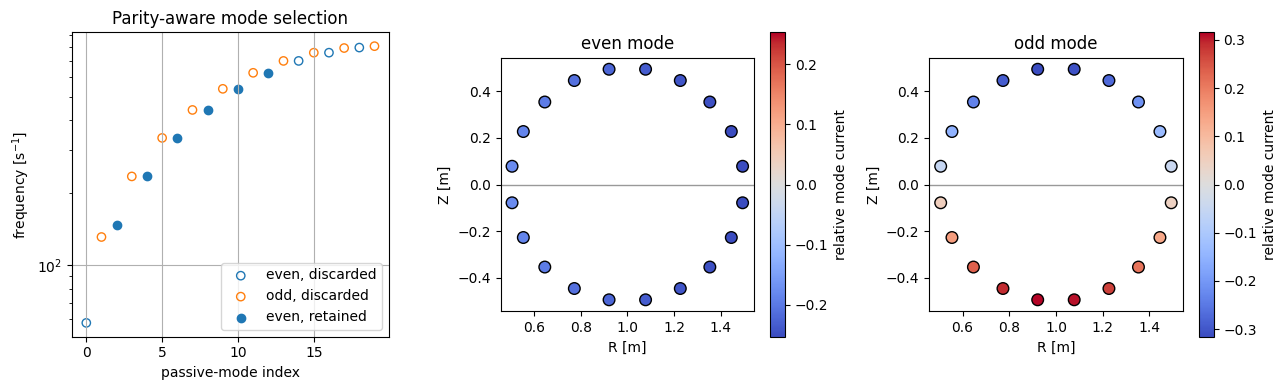

In [10]:
normal_modes = stepping.evol_metal_curr.normal_modes
passive_parity = normal_modes.passive_mode_parity
passive_frequency = normal_modes.w_passive
retained_passive = stepping.evol_metal_curr.selected_modes_mask[n_active:]
passive_centres = np.array(
    [
        [np.mean(element["R"]), np.mean(element["Z"])]
        for element in prepared.passive_coils_data
    ]
)

representative_modes = {
    "even mode": np.flatnonzero(passive_parity > 0)[0],
    "odd mode": np.flatnonzero(passive_parity < 0)[0],
}
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

for parity, label, colour in ((1, "even", "tab:blue"), (-1, "odd", "tab:orange")):
    parity_mask = (passive_parity == parity) & ~retained_passive
    axes[0].scatter(
        np.flatnonzero(parity_mask),
        passive_frequency[parity_mask],
        facecolors="none",
        edgecolors=colour,
        label=f"{label}, discarded",
    )
retained_indices = np.flatnonzero(retained_passive)
axes[0].scatter(
    retained_indices,
    passive_frequency[retained_passive],
    color="tab:blue",
    label="even, retained",
)
axes[0].set_yscale("log")
axes[0].set_xlabel("passive-mode index")
axes[0].set_ylabel("frequency [s$^{-1}$]")
axes[0].set_title("Parity-aware mode selection")
axes[0].grid(True)
axes[0].legend()

for axis, (title, mode_index) in zip(axes[1:], representative_modes.items()):
    amplitudes = normal_modes.Pmatrix[
        n_active:, n_active + mode_index
    ]
    scale = np.max(np.abs(amplitudes))
    points = axis.scatter(
        passive_centres[:, 0],
        passive_centres[:, 1],
        c=amplitudes,
        cmap="coolwarm",
        vmin=-scale,
        vmax=scale,
        s=70,
        edgecolor="k",
    )
    axis.axhline(0.0, color="0.6", linewidth=1)
    axis.set_aspect("equal")
    axis.set_xlabel("R [m]")
    axis.set_ylabel("Z [m]")
    axis.set_title(title)
    fig.colorbar(points, ax=axis, label="relative mode current")

fig.tight_layout()
plt.show()

## 6. Run the controlled evolution

At each 2.5 ms solver step, the PCS evaluates its controllers on two 1.25 ms
substeps and returns one active-voltage vector. The reduced solver then advances
the retained metal modes, plasma current, and profile response. Flat profile
parameters and resistivity are supplied explicitly.

The relinearisation threshold retains the standard relative change in toroidal
current density. Relinearisation coverage belongs to the automated tests, so
this short example does not require a particular number of events.


In [11]:
n_steps = 20
dt = stepping.dt_step
dt_pcs = dt / 2
times = tmin + np.arange(n_steps) * dt
stepping.initialize_from_ICs(eq, profiles)

dynamic_psi = np.zeros((*eq.psi().shape, n_steps))
dynamic_currents = np.zeros((len(stepping.vessel_currents_vec), n_steps))
dynamic_ip = np.zeros(n_steps)
dynamic_shape = np.zeros((len(ctrl_targets), n_steps))
dynamic_z = np.zeros(n_steps)
voltages = np.zeros((n_active, n_steps - 1))
step_times = np.zeros(n_steps - 1)

dynamic_psi[:, :, 0] = stepping.eq1.psi()
dynamic_currents[:, 0] = stepping.vessel_currents_vec
dynamic_ip[0] = stepping.profiles1.Ip
dynamic_shape[:, 0] = plasma_descriptors(stepping.eq1)
dynamic_z[0] = stepping.eq1.Zcurrent()

ip_hist_prev = 0.0
ip_err_prev = 0.0
shape_error_prev = np.zeros(len(ctrl_targets))
shape_history_prev = np.zeros(len(ctrl_targets))
approved_current_prev = initial_active.copy()
approved_voltage_prev = np.zeros(n_active)

for index, time_value in enumerate(times[:-1]):
    result = pcs.calculate_ctrl_voltages(
        t=time_value,
        dt=dt_pcs,
        dt_simulator=dt,
        ip_meas=dynamic_ip[index],
        ip_hist_prev=ip_hist_prev,
        ip_err_prev=ip_err_prev,
        T_meas=dynamic_shape[:, index],
        T_err_prev=shape_error_prev,
        T_hist_prev=shape_history_prev,
        I_approved_prev=approved_current_prev,
        I_meas=dynamic_currents[:n_active, index],
        V_approved_prev=approved_voltage_prev,
        zip_meas=dynamic_z[index] * dynamic_ip[index],
        zipv_meas=0.0,
        active_coil_resists=tokamak.coil_resist[:n_active],
        verbose=False,
    )
    (
        approved_voltage,
        ip_hist_prev,
        ip_err_prev,
        shape_error_prev,
        shape_history_prev,
        approved_current_prev,
        active_resistances,
    ) = result
    voltages[:, index] = approved_voltage
    approved_voltage_prev = approved_voltage.copy()

    start = time.perf_counter()
    stepping.nlstepper(
        plasma_resistivity=1e-7,
        active_voltage_vec=approved_voltage,
        # Lao logic adds one dependent closure coefficient to each stored
        # array; the evolutive interface accepts the independent values only.
        profiles_parameters={
            "alpha": profiles.alpha[:-1].copy(),
            "beta": profiles.beta[:-1].copy(),
        },
        custom_active_coil_resistances=active_resistances,
        linear_only=True,
        target_relative_tol_currents=1e-2,
        target_relative_tol_GS=1e-2,
        working_relative_tol_GS=5e-3,
        max_solving_iterations=20,
        relinearise_threshold=0.05,
        no_GS=False,
        verbose=False,
    )
    step_times[index] = time.perf_counter() - start

    dynamic_psi[:, :, index + 1] = stepping.eq1.psi()
    dynamic_currents[:, index + 1] = stepping.vessel_currents_vec
    dynamic_ip[index + 1] = stepping.profiles1.Ip
    dynamic_shape[:, index + 1] = plasma_descriptors(stepping.eq1)
    dynamic_z[index + 1] = stepping.eq1.Zcurrent()

print(f"Mean evolutive-step time: {np.mean(step_times):.3f} s")
print(f"Maximum |Zcurrent|: {np.max(np.abs(dynamic_z)):.3e} m")


Mean evolutive-step time: 0.020 s
Maximum |Zcurrent|: 3.406e-18 m


## 7. Inspect the result

The first plot compares every controlled quantity with its flat request. The
second shows the active currents and voltages. Finally, parity is checked over
the complete stored trajectory rather than only at initialization.


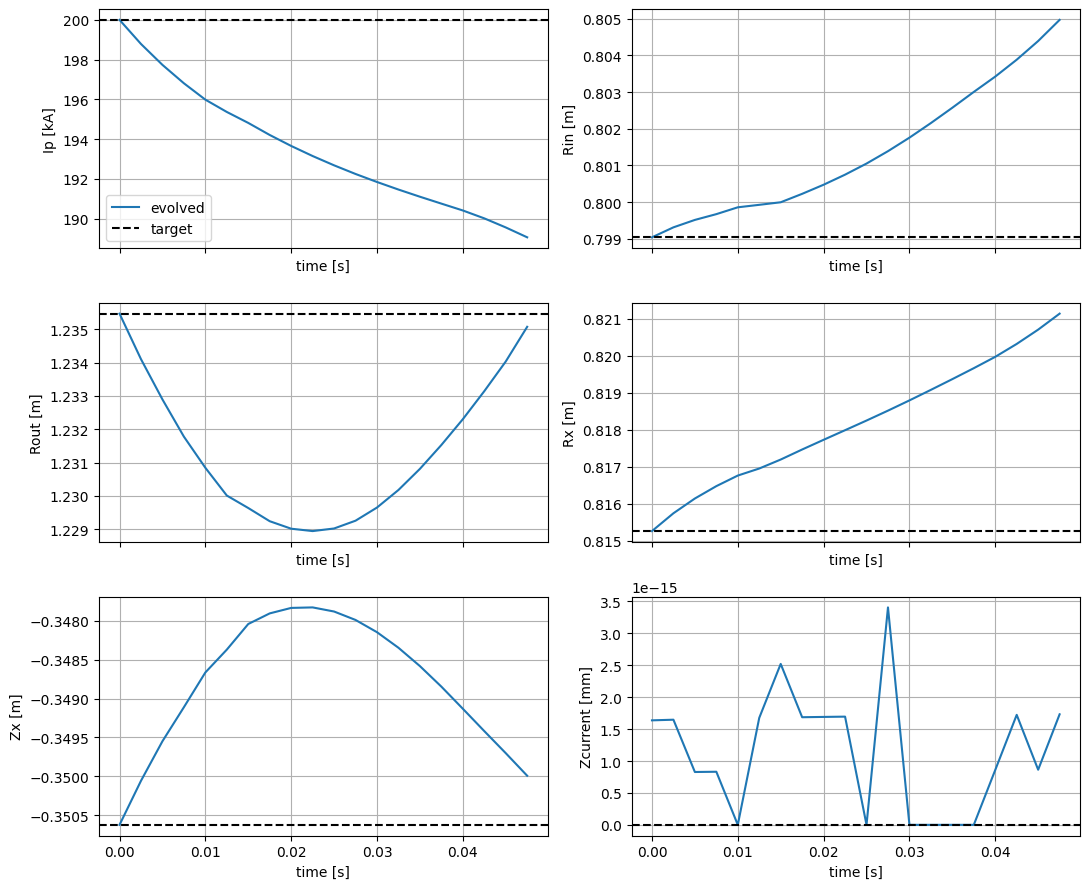

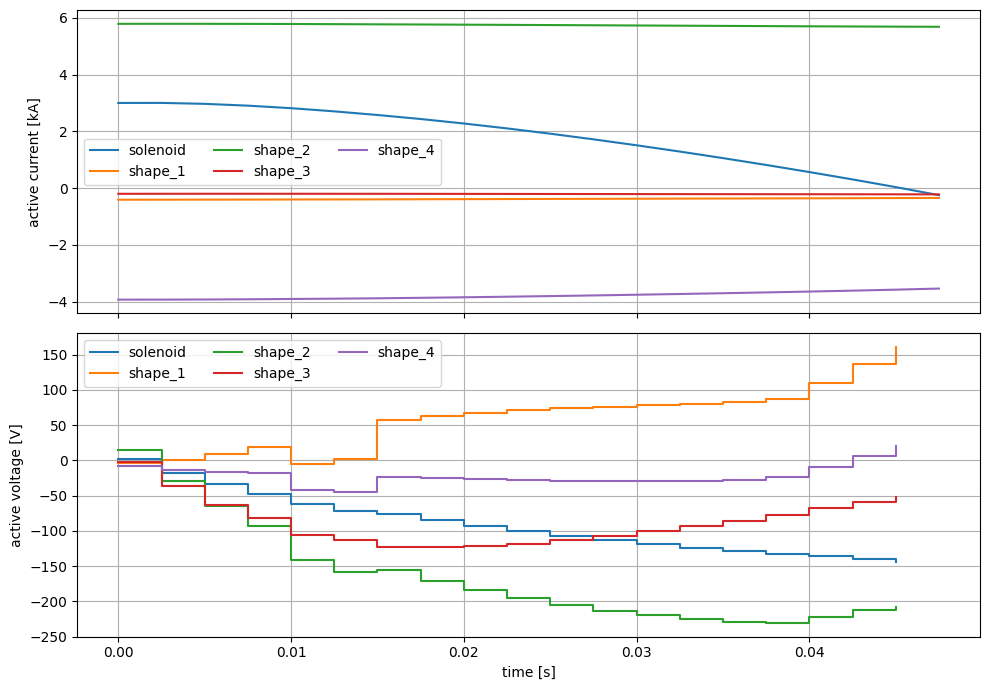

In [12]:
fig, axes = plt.subplots(3, 2, figsize=(11, 9), sharex=True)
axes = axes.ravel()
axes[0].plot(times, dynamic_ip / 1e3, label="evolved")
axes[0].axhline(profiles.Ip / 1e3, color="k", linestyle="--", label="target")
axes[0].set_ylabel("Ip [kA]")
axes[0].legend()

for target_index, target in enumerate(ctrl_targets, start=1):
    axis = axes[target_index]
    axis.plot(times, dynamic_shape[target_index - 1], label="evolved")
    axis.axhline(
        baseline_descriptors[target_index - 1],
        color="k",
        linestyle="--",
        label="target",
    )
    axis.set_ylabel(f"{target} [m]")

axes[5].plot(times, 1e3 * dynamic_z)
axes[5].axhline(0.0, color="k", linestyle="--")
axes[5].set_ylabel("Zcurrent [mm]")
for axis in axes:
    axis.grid(True)
    axis.set_xlabel("time [s]")
fig.tight_layout()
plt.show()

fig, (current_axis, voltage_axis) = plt.subplots(2, 1, figsize=(10, 7), sharex=True)
for coil_index, coil_name in enumerate(active_coils):
    current_axis.plot(
        times,
        dynamic_currents[coil_index] / 1e3,
        label=coil_name,
    )
    voltage_axis.step(
        times[:-1],
        voltages[coil_index],
        where="post",
        label=coil_name,
    )
current_axis.set_ylabel("active current [kA]")
voltage_axis.set_ylabel("active voltage [V]")
voltage_axis.set_xlabel("time [s]")
for axis in (current_axis, voltage_axis):
    axis.grid(True)
    axis.legend(ncol=3)
fig.tight_layout()
plt.show()


In [13]:
flux_parity_errors = [
    relative_reflection_error(dynamic_psi[:, :, index])
    for index in range(n_steps)
]
current_parity_errors = []
for index in range(n_steps):
    current = dynamic_currents[:, index]
    denominator = np.linalg.norm(current)
    current_parity_errors.append(
        0.0
        if denominator == 0
        else np.linalg.norm(reflection_operator @ current - current) / denominator
    )

print("Maximum flux parity error:", max(flux_parity_errors))
print("Maximum metal-current parity error:", max(current_parity_errors))
print(
    "Largest descriptor departure [mm]:",
    1e3 * np.max(np.abs(dynamic_shape - baseline_descriptors[:, None]), axis=1),
)
print(
    "Largest active-current departure [A]:",
    np.max(
        np.abs(dynamic_currents[:n_active] - initial_active[:, None]),
        axis=1,
    ),
)
assert max(flux_parity_errors) < 1e-12
assert max(current_parity_errors) < 1e-12


Maximum flux parity error: 2.116940874056668e-17
Maximum metal-current parity error: 0.0
Largest descriptor departure [mm]: [5.92643884 6.51711168 5.88439602 2.79769088]
Largest active-current departure [A]: [3246.89747213   62.60522865  104.34271132   19.8553951   389.59395891]


## 8. Verify full and reduced symmetric dynamics

As a direct check of the reduction, the linear metal circuit is evolved twice:
once with every passive mode and once with only the even passive modes. Both
start from the same even physical currents and receive the same voltages. Since
the circuit operator commutes with reflection, the full solution cannot acquire
an odd component and the reconstructed physical currents must agree.

This inexpensive comparison isolates the parity reduction itself. The automated
integration test additionally exercises the coupled linear plasma response and
checks the same equivalence over multiple steps.

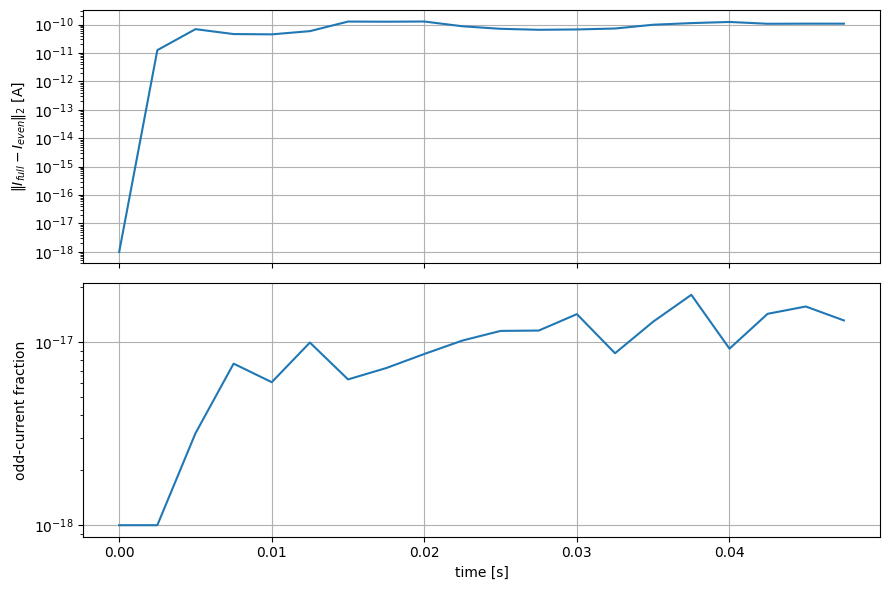

Maximum physical-current difference [A]: 1.2767532227933232e-10
Maximum odd-current fraction: 1.8226917687691924e-17


In [14]:
from freegsnke.circuit_eq_metal import metal_currents


def make_metal_reference(remove_odd_modes):
    return metal_currents(
        eq=eq,
        flag_vessel_eig=True,
        flag_plasma=False,
        max_mode_frequency=np.inf,
        max_internal_timestep=dt,
        full_timestep=dt,
        coil_resist=tokamak.coil_resist,
        coil_self_ind=tokamak.coil_self_ind,
        passive_reflection_operator=passive_reflection_operator,
        remove_odd_passive_modes=remove_odd_modes,
        verbose=False,
    )


full_metal = make_metal_reference(remove_odd_modes=False)
even_metal = make_metal_reference(remove_odd_modes=True)
physical_initial = dynamic_currents[:, 0]
full_state = full_metal.Pm1 @ physical_initial
even_state = even_metal.Pm1 @ physical_initial

full_physical = [physical_initial.copy()]
even_physical = [physical_initial.copy()]
odd_fraction = [0.0]
for voltage in voltages.T:
    full_state = full_metal.stepper(full_state, voltage)
    even_state = even_metal.stepper(even_state, voltage)
    full_current = full_metal.P @ full_state
    even_current = even_metal.P @ even_state
    full_physical.append(full_current)
    even_physical.append(even_current)
    odd_part = 0.5 * (
        full_current - reflection_operator @ full_current
    )
    odd_fraction.append(
        np.linalg.norm(odd_part) / max(np.linalg.norm(full_current), 1.0)
    )

full_physical = np.asarray(full_physical).T
even_physical = np.asarray(even_physical).T
physical_difference = np.linalg.norm(
    full_physical - even_physical, axis=0
)

fig, axes = plt.subplots(2, 1, figsize=(9, 6), sharex=True)
axes[0].semilogy(times, np.maximum(physical_difference, 1e-18))
axes[0].set_ylabel(r"$\|I_{full}-I_{even}\|_2$ [A]")
axes[1].semilogy(times, np.maximum(odd_fraction, 1e-18))
axes[1].set_ylabel("odd-current fraction")
axes[1].set_xlabel("time [s]")
for axis in axes:
    axis.grid(True)
fig.tight_layout()
plt.show()

print("Maximum physical-current difference [A]:", np.max(physical_difference))
print("Maximum odd-current fraction:", np.max(odd_fraction))
assert np.max(physical_difference) < 1e-9
assert np.max(odd_fraction) < 1e-12